# Electrostatic Force and Electric Field

### Assumptions

- The charges are stationary.
- Each charge is treated as a point charge.
- The surrounding medium is a vacuum.
- Relativistic and magnetic effects are neglected.
- The electrostatic interaction follows Coulomb's law.
- The test charge is sufficiently small that it does not alter the source-charge distribution.

## Coulomb's Law

$$F_e = k_e \frac{\left| q_1 \right| \left| q_2 \right|}{r^2}$$ with
$$k_e = \frac{1}{4 \pi \epsilon_0}$$
$\epsilon_0$ describes the permittivity of free space, $\epsilon_0 = 8.8542 \times 10^{-12} \, \mathrm{C^2/N \cdot m^2}$


We can write a displacement vector from $q_1$ to $q_2$
$$\mathbf{r}_{21} = \mathbf{r}_2 - \mathbf{r}_1$$
Furthermore, we can write a unit vector,
$$\hat{\mathbf{r}}_{21} = \frac{\mathbf{r}_{21}}{\left| \mathbf{r}_{21} \right|}$$
Therefore,
$$\mathbf{F}_e = \frac{1}{4 \pi \epsilon_0}  q_1 q_2  \frac{\mathbf{r}_2 - \mathbf{r}_1}{{\left|\mathbf{r}_2 - \mathbf{r}_1\right|}^3}$$

## Electric Field

For the test charge $q_0$,

$$\mathbf{E} = \frac{\mathbf{F}}{q_0}$$
When point charge $q$ located in $\mathbf{r}_q$, 
The electric field on the observation point $\mathbf{r}_q$ is

$$\mathbf{E} = \frac{1}{4 \pi \epsilon_0}  q  \frac{\mathbf{r} - \mathbf{r}_q}{{\left|\mathbf{r} - \mathbf{r}_q\right|}^3}$$

An electric field is a physical state established in space by a source charge, whereas an electric force is the force exerted on a specific charge placed within that space.

## Principle of superposition

We can calculate the net electric field with the summation of vectors,
$$\mathbf{E}_{net} = \frac{1}{4 \pi \epsilon_0} \sum_{i=1}^N q_i \frac{\mathbf{r} - \mathbf{r}_i}{{\left|\mathbf{r} - \mathbf{r}_i\right|}^3} $$

## Gauss's law
$$\oint_S \mathbf{E} \cdot d\mathbf{A} = \frac{Q_\text{enc}}{\epsilon_0}$$

---
# Case 1: Electric Field of a Single Charge

## Given conditions
$$q = 1.0 \mathrm \, {nC}$$
$$\mathbf{r} = (0.10, 0.00)  \mathrm{m}$$

## Question 
1. What is the direction of the electric field?
2. What happens when we change the charge to $q = -1.0 \mathrm \,{nC}$?
3. What happens to the magnitude of the field when we double the distance?

In [1]:
from src.point_charge_electric_field import electric_field_point_charge, electric_field_multiple_charges
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
charge = 1.0e-9
charge_position = np.array([0.0, 0.0])
observation_point = np.array([0.1, 0.0])

electric_field = electric_field_point_charge(
    observation_point,
    charge_position,
    charge,
)

print("Electric field [N/C]:", electric_field)
print("Magnitude [N/C]:", np.linalg.norm(electric_field))

Electric field [N/C]: [898.75517923   0.        ]
Magnitude [N/C]: 898.7551792261171


## Results

$$\mathbf{E} = [898.8, 0]  \mathrm{N/C}$$
$$\text{Magnitude}  = 898.8 \mathrm{N/C}$$

## Physical interpretations with answering the questions.

Q1. What is the direction of the electric field?

A1. 구한 전기장은 $x+$ 방향을 가진다.

The source charge is positive, so the electric field points away from the charge. Since the observation point is located on the positive $x$-axis, the field points in the $+x$-direction.

---

Q2. What happens when we change the charge to $q = -1.0 \mathrm \,{nC}$?

A2. 전기장의 크기는 동일하나 방향이 반대가 된다.
The magnitude remains unchanged because the magnitude depends on $q$. However, the direction is reversed.

---

Q3. What happens to the magnitude of the field when we double the distance?

A3. 전기장의 크기가 $\frac{1}{4}$배 된다.

Because the field magnitude follows an inverse-square relation,

$$E\propto\frac{1}{r^2},$$

doubling the distance reduces the field magnitude to one fourth:

$$E(2r)=\frac{1}{4}E(r).$$

---
# Case 2: Two Euqal Positive Charges

## Given conditions
$$q_1 = q_2 = q$$
$$\mathbf{r}_1 = (-1.0, 0)\quad \mathbf{r}_2 = (1.0, 0) $$

## Goal
Confrim the value $$\mathbf{E}_\text{net}(0, 0) = 0$$

Net electric field [N/C]: [0. 0.]


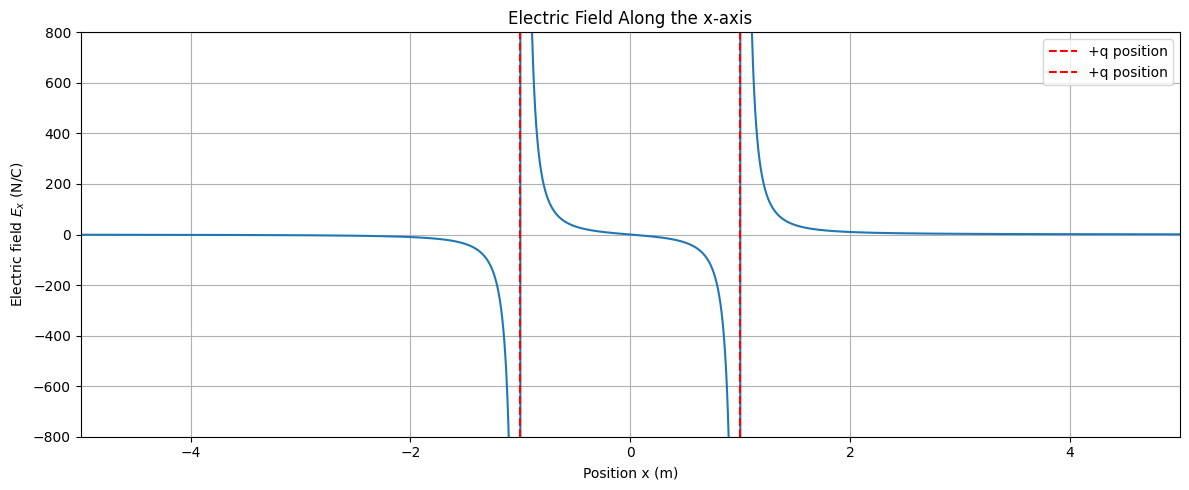

In [4]:
figure_dir = Path("../figures/01_electrostatic_force_and_electric_field")
figure_dir.mkdir(parents=True, exist_ok=True)

charges_2 = np.array([1.0e-9, 1.0e-9])

charge_positions_2 = np.array([
    [-1, 0.0],
    [1, 0.0],
])

observation_point_2 = np.array([0.0, 0.0])

net_field_2 = electric_field_multiple_charges(observation_point_2, charge_positions_2, charges_2)

print("Net electric field [N/C]:", net_field_2)

#############

x_2 = np.linspace(-5, 5, 10000)
E_x_2 = np.zeros_like(x_2)

for i, x_value in enumerate(x_2):
    observation_point_2 = np.array([x_value, 0.0])

    try:
        electric_field_2 = electric_field_multiple_charges(observation_point_2, charge_positions_2, charges_2)

        E_x_2[i] = electric_field_2[0]
        

    except ValueError:
        E_x_2[i] = np.nan
        


plt.figure(figsize=(12, 5))

plt.plot(x_2, E_x_2)

plt.axvline(-1, linestyle="--", label="+q position", color = "red")
plt.axvline(1, linestyle="--", label="+q position", color = "red")

plt.xlim(-5, 5)
plt.ylim(-800, 800)

plt.xlabel("Position x (m)")
plt.ylabel(r"Electric field $E_x$ (N/C)")
plt.title("Electric Field Along the x-axis")
plt.grid(True)
plt.legend()

plt.tight_layout()

file_stem = figure_dir / "case_02_Electric_Field_Along_x_axis"

plt.savefig(f"{file_stem}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{file_stem}.pdf", bbox_inches="tight")
        
plt.show()

## Results
$$\mathbf{E}_\text{net}(0, 0) = 0$$

## Physical interpretations
전하량과 부호가 같은 두 전하에 의해 두 전하 중심점에서의 전기장의 크기는 0이 된다. 각 전하에 의해 생성된 두 개의 장벡터가 서로 다른 방향으로 중심점에 작용하기에 상쇄되기 때문이다.

$$\mathbf E_{\mathrm{net}}(0,0)=\mathbf 0$$

At the midpoint, the two charges produce electric fields of equal
magnitude. Since both charges are positive, each field points away from
its source charge. The two field vectors therefore point in opposite
directions and cancel:

$$\mathbf E_1(0,0)=-\mathbf E_2(0,0)$$

Hence,

$$\mathbf E_{\mathrm{net}}(0,0)=\mathbf 0$$

---
# Case 3: Electric Dipole

## Given conditions
$$q_1 = +q, \quad q_2 = -q$$
$$q = 1.0\times10^{-9} \, {nC}$$
$$\mathbf{r}_1 = (1.0, 0),\quad \mathbf{r}_2 = (1.0, 0) $$

## Questions
1. How is Case 3 different from Case 2 in the dipole-moment field?
2. How to decide the direction of the electric field on the symmetric axis?
3. Are there any points where the electric field becomes zero?

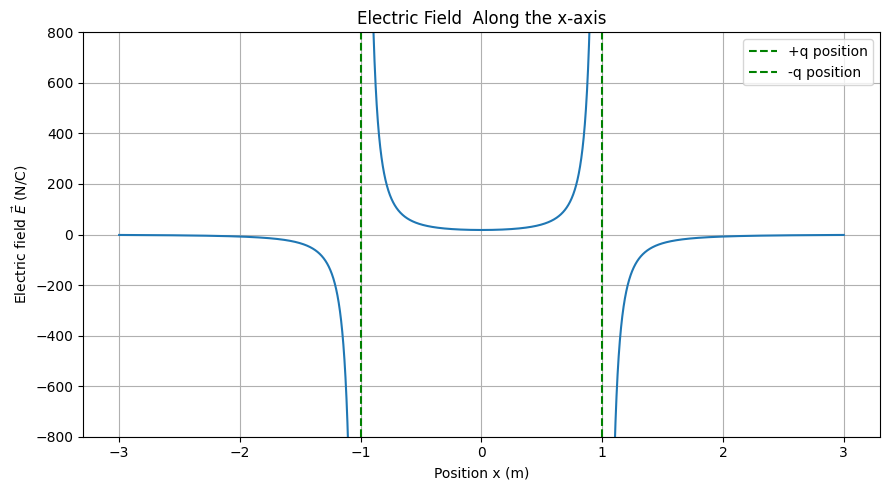

In [8]:
figure_dir = Path("../figures/01_electrostatic_force_and_electric_field")
figure_dir.mkdir(parents=True, exist_ok=True)

charges_3 = np.array([1.0e-9, -1.0e-9])
charge_positions_3 = np.array([[-1, 0], [1, 0]])

x = np.linspace(-3, 3, 10000)
E_x = np.zeros_like(x)


for i, x_value in enumerate(x):
    observation_point_3 = np.array([x_value, 0.0])

    try:
        electric_field = electric_field_multiple_charges(observation_point_3, charge_positions_3, charges_3)

        E_x[i] = electric_field[0]
        

    except ValueError:
        E_x[i] = np.nan
        

plt.figure(figsize=(9, 5))
plt.ylim(-800, 800)

plt.plot(x, E_x)

plt.axvline(-1, linestyle="--", label="+q position", color = "green")
plt.axvline(1, linestyle="--", label="-q position", color = "green")

plt.xlabel("Position x (m)")
plt.ylabel(r"Electric field $\vec{E}$ (N/C)")
plt.title("Electric Field  Along the x-axis")

plt.grid(True)
plt.legend()

plt.tight_layout()

file_stem = figure_dir / "case_03_Electric_Field_Along_x_axis"

plt.savefig(f"{file_stem}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{file_stem}.pdf", bbox_inches="tight")

plt.show()
    

## Results
We can see the results about Case 3.

## Physical interpretations and answering questions

Q1. How is Case 3 different from Case 2 in the dipole-moment field?

A1. Case 2의 경우 전기장의 크기가 0이 되는 지점이 존재하지만 Case 3의 경우 전기장의 크기가 영이 되는 지점이 존재하지 않는 다는 것을 위의 그래프들을 통해 확인할 수 있다.

---

Q2. How to decide the direction of the electric field on the symmetric axis?

A2. 각 전하가 생성하는 장의 방향을 각 전하와의 상대적 위치에 따라 판단한 뒤, 벡터합하여 알 수 있다. 결과론적으론, 그래프의 부호를 보고 판단할 수 있다.

At the midpoint, the positive charge produces an electric field directed
away from itself, toward the positive $x$-direction. The negative
charge produces a field directed toward itself, which is also the
positive $x$-direction.

Therefore, the two electric-field vectors reinforce each other.

---

Q3. Are there any points where the electric field becomes zero?

A3. 존재하지 않는다. 전하량이 같고 부호가 다른 두 쌍극자 사이에 관찰 전하가 위치한다면 관찰 전하에 두 쌍극자가 작용하는 전기장은 동일한 방향을 가진다. 또, 두 전하의 바깥 영역에서는 관찰 전하에 작용하는 전기장의 방향이 반대이지만, 가까운 쌍극자가 만드는 전기장의 크기는 유한한 거리에서 항상 상쇄되지 않는다. 두 쌍극자로부터 관찰 전하가 무한히 멀어질 때 전기장의 크기는 0으로 수렴하지만, 0이 되는 지점은 존재하지 않는다.

There is no finite point at which the net electric field of two equal and opposite point charges becomes exactly zero. Between the charges, the two fields point in the same direction. Outside the charges, they
point in opposite directions, but the field generated by the closer charge always has the greater magnitude. The field approaches zero only as the distance tends to infinity.

---
# Case 4: Two-Dimensional Field Visualization

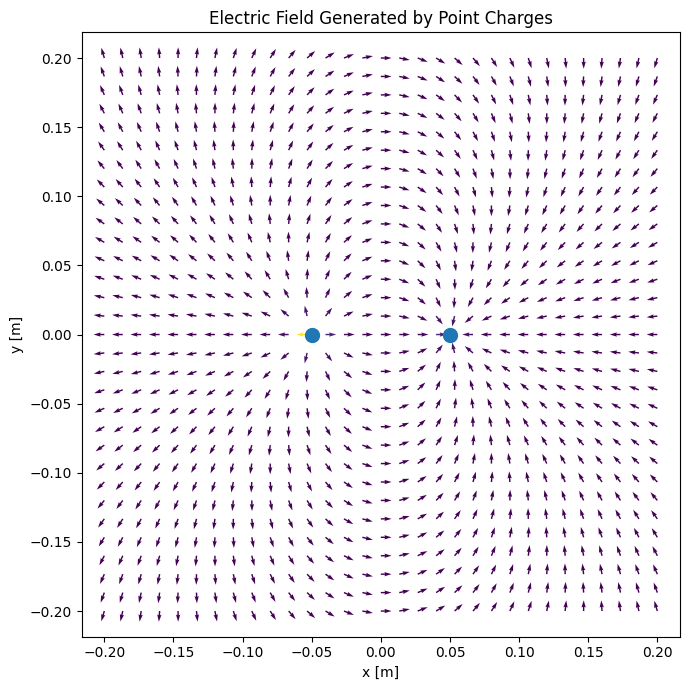

In [7]:
figure_dir = Path("../figures/01_electrostatic_force_and_electric_field")
figure_dir.mkdir(parents=True, exist_ok=True)

charges_4 = np.array([
    1.0e-9,
    -1.0e-9,
])

charge_positions_4 = np.array([
    [-0.05, 0.0],
    [ 0.05, 0.0],
])

x_4 = np.linspace(-0.2, 0.2, 31)
y_4 = np.linspace(-0.2, 0.2, 31)

X_4, Y_4 = np.meshgrid(x_4, y_4)

E_x_4 = np.zeros_like(X_4)
E_y_4 = np.zeros_like(Y_4)

for i in range(X_4.shape[0]):
    for j in range(X_4.shape[1]):
        observation_point_4 = np.array([X_4[i, j], Y_4[i, j]])

        try:
            electric_field_4 = electric_field_multiple_charges(observation_point_4, charge_positions_4, charges_4)

            E_x_4[i, j] = electric_field_4[0]
            E_y_4[i, j] = electric_field_4[1]

        except ValueError:
            E_x_4[i, j] = np.nan
            E_y_4[i, j] = np.nan

field_magnitude_4 = np.sqrt(E_x_4**2 + E_y_4**2)

E_x_normalized_4 = np.divide(
    E_x_4,
    field_magnitude_4,
    out=np.zeros_like(E_x_4),
    where=field_magnitude_4 != 0,
)

E_y_normalized_4 = np.divide(
    E_y_4,
    field_magnitude_4,
    out=np.zeros_like(E_y_4),
    where=field_magnitude_4 != 0,
)

plt.figure(figsize=(7, 7))

plt.quiver(
    X_4,
    Y_4,
    E_x_normalized_4,
    E_y_normalized_4,
    field_magnitude_4,
)

plt.scatter(
    charge_positions_4[:, 0],
    charge_positions_4[:, 1],
    s=100,
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Electric Field Generated by Point Charges")
plt.axis("equal")

plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)
plt.axis("equal")

plt.tight_layout()

file_stem = figure_dir / "case_04_Electric_Field_Generalted_by_Point_Charges"

plt.savefig(f"{file_stem}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{file_stem}.pdf", bbox_inches="tight")

plt.show()

## Conlusion
In this notebook, Coulomb's law was used to describe the electrostatic
force between point charges. The electric field was then introduced as
a vector field determined by the source charges and independent of the
test charge.

The principle of superposition was implemented numerically to calculate
the net electric field generated by multiple point charges. The results
verified the inverse-square dependence, the direction of the electric
field for positive and negative charges, and the cancellation caused by
symmetry.

This framework provides the foundation for studying electric flux and
Gauss's law in the next notebook.